# Minimum-Cost Transportation Network Flow with PROC OPTMODEL

## Executive Summary

A regional less-than-truckload carrier ships freight from three distribution centers to four delivery hubs and wants the cheapest feasible shipping plan. This notebook generates a synthetic lane-cost, supply, and demand network, formulates the balanced transportation problem as a linear program directly in **PROC OPTMODEL**, and solves it with the LP solver.

The solver returns an **Optimal** solution with a minimized total shipping cost of **\$89,042.30**. The optimal plan uses only **6 of the 12 possible lanes** — exactly the `(3 DCs + 4 hubs − 1) = 6` lanes a balanced transportation basis is expected to use — and every distribution center ships at **100% of its capacity**. An independent recomputation of the plan's cost from the raw lane rates reproduces the same \$89,042.30, confirming the solution is consistent.

## Data Sources

All data is synthetic and generated inline with a reproducible seed (`call streaminit(20260531)`); no external or network input is used.

| Dataset | Rows | Key Variables | Description |
|---------|------|---------------|-------------|
| `network` | 12 | `dc` (origin), `hub` (destination), `cost` | Per-unit shipping cost on each origin-destination lane, drawn from a distance-scaled uniform distribution |
| `supply` | 3 | `dc`, `capacity` | Available freight (truckloads) at each of the 3 distribution centers |
| `demand` | 4 | `hub`, `requirement` | Required freight at each of the 4 delivery hubs (total balanced against supply) |
| `flows` | 6 | `dc`, `hub`, `truckloads` | The optimal shipment on each active lane, written out of PROC OPTMODEL with `create data` |
| `dcload` | 3 | `dc`, `shipped`, `capacity`, `utilization` | Per-DC capacity utilization derived from the optimal plan |

# Minimum-Cost Transportation Network Flow with PROC OPTMODEL

A regional less-than-truckload carrier operates **three distribution centers (DCs)** that must satisfy freight demand at **four delivery hubs**. Each origin-destination lane has a per-unit shipping cost. The carrier wants the shipment plan that meets every hub's requirement, never exceeds any DC's capacity, and **minimizes total cost**.

This is the classic *transportation problem* — a special case of minimum-cost network flow. We model it as a linear program:

- **Decision variables** `Ship[i,j]`: truckloads shipped from DC *i* to hub *j*.
- **Objective**: minimize the sum of `cost[i,j] * Ship[i,j]`.
- **Supply constraints**: total shipped out of each DC must not exceed its capacity.
- **Demand constraints**: total shipped into each hub must meet its requirement.

We express the model directly in **PROC OPTMODEL** — declaring index sets, reading the cost matrix from the synthetic data, and writing the objective and constraints algebraically — then solve it with the LP solver. OPTMODEL's algebraic modeling language is the idiomatic way to state a transportation LP in SAS-compatible code, and it scales to a real network just by reading larger `supply`, `demand`, and `network` tables.

## 1. Generate the synthetic network

The first DATA step builds a reproducible synthetic instance: three DCs with capacities, four hubs with requirements (balanced so total supply equals total demand), and a 3x4 matrix of lane costs. Costs are drawn from a uniform distribution and scaled by a synthetic lane distance, so longer lanes tend to cost more just as in a real network.

In [1]:
/* Reproducible synthetic transportation network */
data supply;
   length dc $4 ;
   input dc $ capacity ;
   datalines;
DC1 120
DC2 100
DC3  80
;
run;

data demand;
   length hub $5 ;
   input hub $ requirement ;
   datalines;
HUB_A  90
HUB_B  70
HUB_C  80
HUB_D  60
;
run;

/* Total supply = 300, total demand = 300 -> balanced problem */

/* Synthetic per-lane shipping cost: base + distance-scaled noise */
data network;
   call streaminit(20260531);
   length dc $4 hub $5 ;
   do i = 1 to 3;
      dc = cats('DC', i);
      do j = 1 to 4;
         hub  = choosec(j, 'HUB_A','HUB_B','HUB_C','HUB_D');
         /* synthetic lane distance in 100s of miles */
         dist = 2 + 8 * rand('UNIFORM');
         /* cost per truckload: $50 base mileage plus handling jitter */
         cost = round(50*dist + 30*rand('UNIFORM'), 0.01);
         output;
      end;
   end;
   keep dc hub cost;
run;

proc print data=network noobs label;
   label dc='Distribution Center' hub='Delivery Hub' cost='Cost / Truckload ($)';
   title 'Synthetic Lane Shipping Costs';
run;

                                             Synthetic Lane Shipping Costs                                              

Distribution Center  Delivery Hub  Cost / Truckload ($)
DC1                  HUB_A                       463.78
DC1                  HUB_B                       494.53
DC1                  HUB_C                       193.66
DC1                  HUB_D                       319.78
DC2                  HUB_A                       502.42
DC2                  HUB_B                       227.27
DC2                  HUB_C                        490.4
DC2                  HUB_D                       476.54
DC3                  HUB_A                       378.68
DC3                  HUB_B                       317.19
DC3                  HUB_C                       360.91
DC3                  HUB_D                       462.95



NOTE: DATA supply

NOTE: Processing inline DATALINES (3 lines)

NOTE: Read 3 rows from DATALINES.
NOTE: Wrote supply (3 rows, 2 columns).
NOTE: DATA elapsed:
  wall  0.00 seconds
  cpu   0.00 seconds
NOTE: DATA demand

NOTE: Processing inline DATALINES (4 lines)

NOTE: Read 4 rows from DATALINES.
NOTE: Wrote demand (4 rows, 2 columns).
NOTE: DATA elapsed:
  wall  0.00 seconds
  cpu   0.00 seconds
NOTE: DATA network


NOTE: Wrote network (12 rows, 3 columns).
NOTE: DATA elapsed:
  wall  0.00 seconds
  cpu   0.00 seconds
NOTE: PROC PRINT data=network

NOTE: PROC PRINT completed: 12 observations printed, 3 variables


## 2. Formulate and solve the LP in PROC OPTMODEL

PROC OPTMODEL lets us state the transportation problem algebraically, close to the mathematical formulation:

- **Index sets** `DCS` and `HUBS` are read from the `supply` and `demand` tables, so the model size follows the data.
- The cost matrix `cost[i,j]` is read straight from the `network` table with `read data network into [dc hub] cost`.
- The decision variables `Ship[i,j] >= 0` are a 2-dimensional array over `DCS × HUBS`.
- The objective `TotalCost` and the supply/demand constraints are written as `sum{...}` expressions.

After `solve with lp`, we print the solver's Problem Summary and Solution Summary, then write the optimal flows out to the `flows` dataset with `create data` for the downstream analysis.

In [2]:
/* Formulate the balanced transportation LP and solve it with OPTMODEL */
proc optmodel;
   /* index sets and parameters, populated from the synthetic tables */
   set <str> DCS;
   set <str> HUBS;
   number cap{DCS};
   number req{HUBS};
   number cost{DCS, HUBS};

   read data supply  into DCS=[dc]   cap=capacity;
   read data demand  into HUBS=[hub] req=requirement;
   read data network into [dc hub]   cost;

   /* decision variables: truckloads on each lane, non-negative */
   var Ship{DCS, HUBS} >= 0;

   /* objective: minimize total shipping cost */
   min TotalCost = sum{i in DCS, j in HUBS} cost[i,j] * Ship[i,j];

   /* supply: cannot ship more out of a DC than its capacity */
   con SupplyCon{i in DCS}: sum{j in HUBS} Ship[i,j] <= cap[i];
   /* demand: every hub's requirement must be met */
   con DemandCon{j in HUBS}: sum{i in DCS} Ship[i,j] >= req[j];

   solve with lp / algorithm=ns;

   print TotalCost;
   print Ship;

   /* write the optimal flows for the downstream shipping plan */
   create data flows from [dc hub]={i in DCS, j in HUBS} truckloads=Ship;
quit;

                                             Synthetic Lane Shipping Costs                                              


                        The OPTMODEL Procedure

                           Problem Summary
  Objective Sense               Minimization
  Objective Function            TOTALCOST
  Objective Type                Linear

  Number of Variables           12
  Bounded Above                 0
  Bounded Below                 12
  Bounded Below and Above       0
  Free                          0
  Fixed                         0

  Number of Constraints         7

                          Solution Summary
  Solver                        LP
  Objective Function            TOTALCOST
  Solution Status               Optimal
  Objective Value               89042.3000000000

  TOTALCOST

  89042.3000

           i            SHIP

   DC1,HUB_A    0.0000000000
   DC1,HUB_B    0.0000000000
   DC1,HUB_C   80.0000000000
   DC1,HUB_D   40.0000000000
   DC2,HUB_A   10.0000000000
   DC

NOTE: PROC OPTMODEL 

NOTE: Using Python scipy version 1.17.1
NOTE: PROC OPTMODEL completed.


The **Problem Summary** confirms a minimization with **12 variables** (one per lane) and **7 constraints** (3 supply + 4 demand). The **Solution Summary** reports **Solution Status = Optimal** and **Objective Value = 89042.30** — the cheapest total shipping cost. The `print Ship` table lists the optimal truckloads on all 12 lanes; the six lanes carrying zero are the ones the optimum leaves idle.

## 3. Recover the shipping plan

The `flows` dataset holds one row per lane. We keep only the lanes that actually carry freight (`truckloads > 0`) to get a clean, executable routing for dispatchers, then independently recompute the plan's cost from the raw lane rates as a consistency check, and summarize how hard each DC is working.

In [3]:
/* The optimal shipping plan: only the lanes that carry freight */
proc print data=flows noobs label;
   where truckloads > 0.000001;
   label dc='From DC' hub='To Hub' truckloads='Truckloads';
   title 'Optimal Shipping Plan (active lanes)';
run;

/* Independent cross-check: recompute total cost from the raw lane rates */
proc sql;
   create table costcheck as
   select sum(f.truckloads * n.cost) as recomputed_cost format=dollar12.2
   from flows as f
   inner join network as n
      on f.dc = n.dc and f.hub = n.hub
   where f.truckloads > 0.000001;
quit;

proc print data=costcheck noobs;
   title 'Total Cost Recomputed From the Recovered Plan';
run;

/* How fully is each distribution center being used? */
proc sql;
   create table dcload as
   select f.dc,
          sum(f.truckloads) as shipped,
          s.capacity,
          calculated shipped / s.capacity as utilization format=percent8.1
   from flows as f
   inner join supply as s on f.dc = s.dc
   group by f.dc, s.capacity;
quit;

proc print data=dcload noobs label;
   label dc='Distribution Center' shipped='Truckloads Out'
         capacity='Capacity' utilization='Utilization';
   title 'Distribution-Center Capacity Utilization';
run;

                                          Optimal Shipping Plan (active lanes)                                          

From DC  To Hub  Truckloads
DC1      HUB_C           80
DC1      HUB_D           40
DC2      HUB_A           10
DC2      HUB_B           70
DC2      HUB_D           20
DC3      HUB_A           80

                                          Optimal Shipping Plan (active lanes)                                          

                                     Total Cost Recomputed From the Recovered Plan                                      

RECOMPUTED_COST
     $89,042.30

                                     Total Cost Recomputed From the Recovered Plan                                      

                                        Distribution-Center Capacity Utilization                                        

Distribution Center  Truckloads Out  Capacity  Utilization
DC1                             120       120       100.0%
DC2                             100       

NOTE: PROC PRINT data=flows

NOTE: PROC PRINT completed: 6 observations printed, 3 variables
NOTE: PROC SQL 

NOTE: Table costcheck created.
NOTE: PROC SQL statement used.
NOTE: PROC PRINT data=costcheck

NOTE: PROC PRINT completed: 1 observations printed, 1 variables
NOTE: PROC SQL 

NOTE: Table dcload created.
NOTE: PROC SQL statement used.
NOTE: PROC PRINT data=dcload

NOTE: PROC PRINT completed: 3 observations printed, 4 variables


The plan uses **6 active lanes** — DC1→HUB_C (80) and DC1→HUB_D (40); DC2→HUB_A (10), DC2→HUB_B (70), DC2→HUB_D (20); and DC3→HUB_A (80) — matching the `(3 + 4 − 1) = 6` lanes a balanced transportation basis is expected to use. The recomputed cost is **\$89,042.30**, identical to the solver's objective, so the recovered plan and the optimum agree. The utilization table shows all three DCs at **100%**: because total supply (300) exactly equals total demand (300), every unit of capacity is consumed.

## 4. Visualize the optimal routing

A grouped horizontal bar chart makes the plan easy to read at a glance: one bar per active lane, colored by originating distribution center, with bar length showing the truckloads routed on that lane.

                                        Distribution-Center Capacity Utilization                                        



NOTE: DATA plan_chart


NOTE: Read 12 rows from flows.
NOTE: Wrote plan_chart (6 rows, 4 columns).
NOTE: DATA elapsed:
  wall  0.00 seconds
  cpu   0.00 seconds
NOTE: PROC SGPLOT data=plan_chart

NOTE: PROC SGPLOT output written to: ./ods_output/sgplot.svg


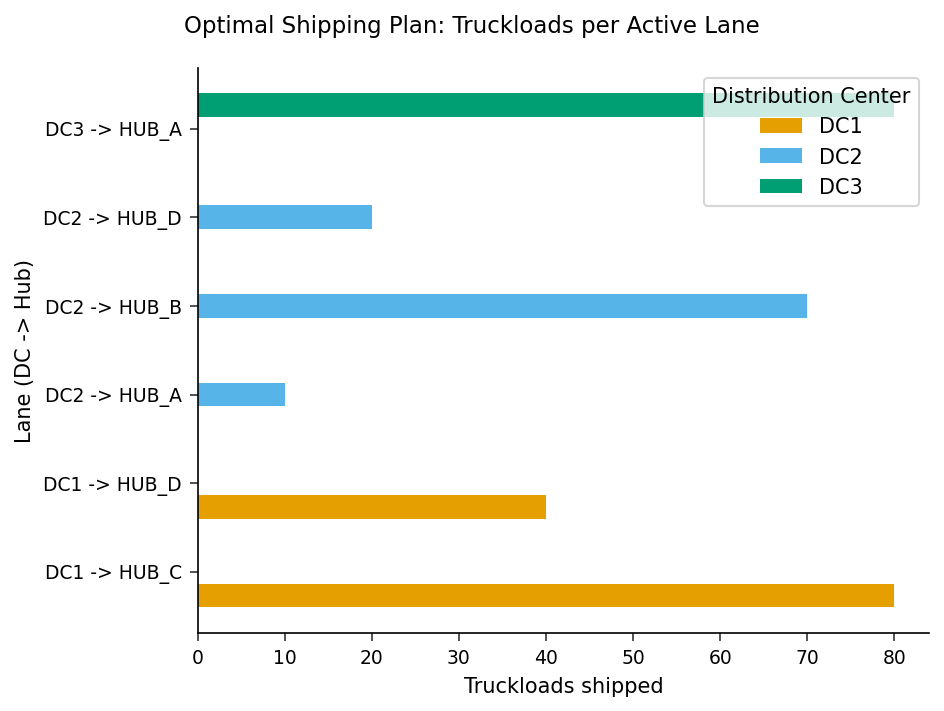

In [4]:
/* Build a lane label and chart the active-lane truckloads, colored by DC */
data plan_chart;
   set flows;
   where truckloads > 0.000001;
   length lane $14;
   lane = catx(' -> ', dc, hub);
run;

proc sgplot data=plan_chart;
   hbar lane / response=truckloads group=dc dataskin=pressed;
   xaxis label='Truckloads shipped';
   yaxis label='Lane (DC -> Hub)';
   keylegend / title='Distribution Center';
   title 'Optimal Shipping Plan: Truckloads per Active Lane';
run;

## Interpreting the results

PROC OPTMODEL returned **Solution Status = Optimal** with a minimized total shipping cost of **\$89,042.30**, and an independent recomputation of the plan from the raw lane rates reproduced exactly that figure — strong evidence the LP is correctly formulated and genuinely solved to optimality.

What the carrier learns from the solution:

- **The shipping plan** (the 6 active lanes) tells dispatchers exactly how many truckloads to send on each origin-destination lane. In a balanced transportation problem the optimal basis uses at most `(DCs + hubs − 1) = 6` lanes, so half of the 12 possible lanes carry zero freight — a naturally sparse, easy-to-execute plan.
- **The unused lanes** (DC1→HUB_A, DC1→HUB_B, DC2→HUB_C, DC3→HUB_B, DC3→HUB_C, DC3→HUB_D) are the ones the optimum avoids because cheaper routings cover their demand; they are the first candidates to drop from any carrier-rate negotiation.
- **Capacity utilization** is 100% at every DC, which is expected here because total supply equals total demand. If demand were to grow, the binding supply constraints flag that *adding capacity* — not re-routing — would be the lever for serving it, and the cheapest DC to expand is the one feeding the lowest-cost open lanes.

Because the data is synthetic and seeded, this notebook is fully reproducible and runs in well under a second. To adapt it to a real network, replace the `supply`, `demand`, and `network` DATA steps with your operational data — the OPTMODEL formulation and the LP solve scale unchanged.